/home/hongyp007/anaconda3/envs/yp/lib/python3.14/site-packages/astropy/units/equivalencies.py:150: RuntimeWarning: divide by zero encountered in divide
  (si.m, si.Hz, lambda x: c / x),
/data9/hongyp/GRB251013C/GRB_fitting/grb/utils.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ind

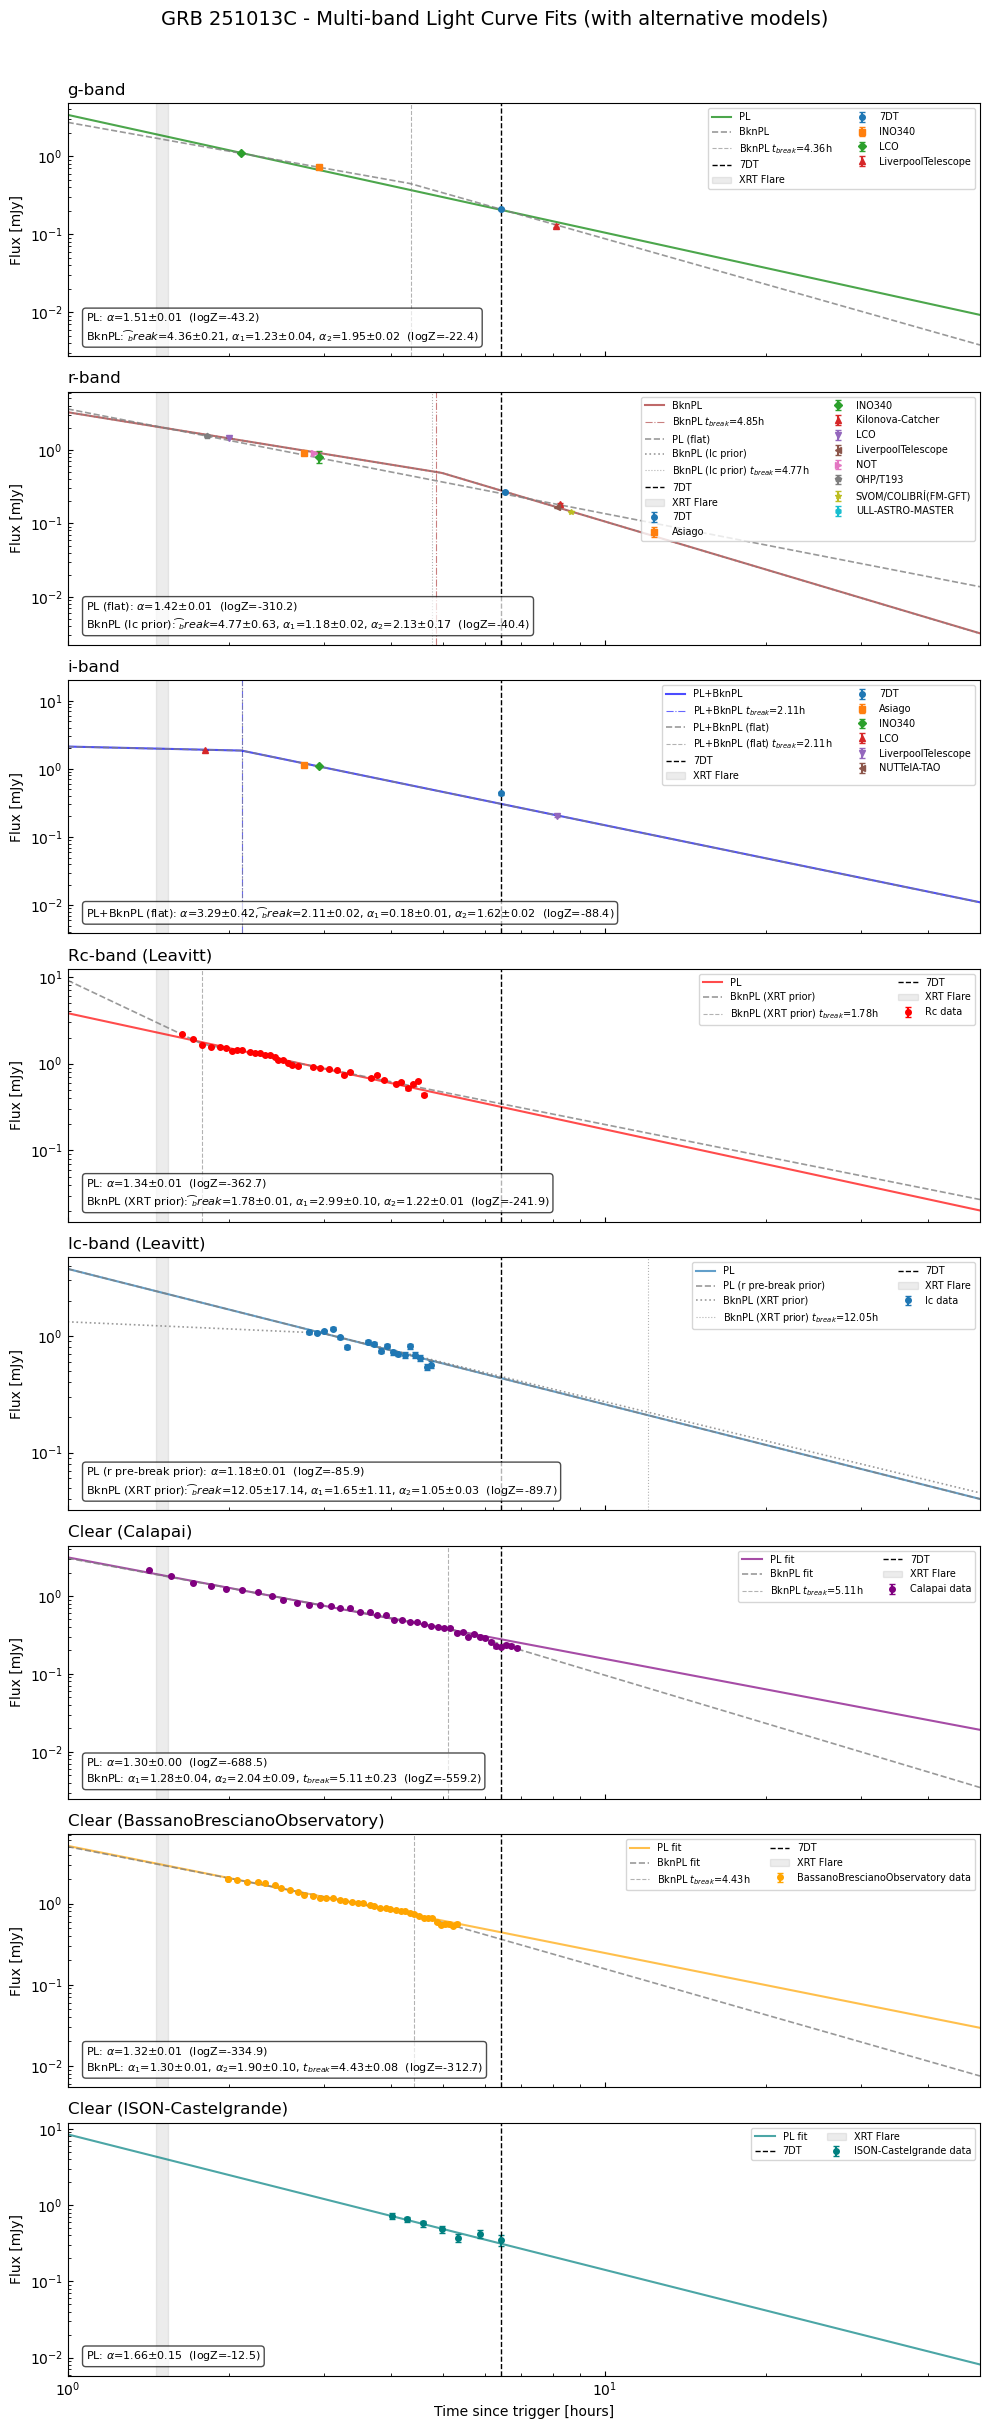

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from grb.functions import power_law, broken_power_law
from grb.io import read_data, filter_data

# --- Load results ---
with open("fit_results_var.pkl", "rb") as f:
    data = pickle.load(f)
with open("var_model_results.pkl", "rb") as f:
    var_data = pickle.load(f)
with open("clear_band_results.pkl", "rb") as f:
    clear_data = pickle.load(f)

# --- Load raw circular data to get facility info ---
df_circ = read_data("circular", add_converted_flux=True)

# Per-band filtering (matching run.ipynb)
band_filters = {
    "g":  dict(filter_name=["g"], remove_upper_limits=True, exclude_time_range=(20, 1e4)),
    "r":  dict(filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4)),
    "i":  dict(filter_name="i", remove_upper_limits=True),
    "Rc": dict(filter_name=["Rc"], remove_upper_limits=True, facility_name="Leavitt"),
    "Ic": dict(filter_name=["Ic"], remove_upper_limits=True, facility_name="Leavitt"),
}
band_dfs = {band: filter_data(df_circ, **filt) for band, filt in band_filters.items()}

# --- Facility color palette (auto-assigned per band) ---
_facility_cmap = plt.cm.tab10
def _get_facility_colors(facilities):
    return {fac: _facility_cmap(i) for i, fac in enumerate(sorted(facilities))}

_markers = ["o", "s", "D", "^", "v", "<", ">", "p", "*", "h"]

# --- Key times (hours after trigger) ---
trigger = datetime(2025, 10, 13, 17, 39, 42)
t_7dt = (datetime(2025, 10, 14, 0, 4, 15) - trigger).total_seconds() / 3600  # 6.409 h
t_flare_start = 5265 / 3600  # 1.4625 h
t_flare_end = 5528 / 3600    # 1.5356 h

# --- Band config: (color, model_func, baseline_label) ---
bands = ["g", "r", "i", "Rc", "Ic"]
band_config = {
    "g":  {"color": "green",  "model": lambda t, p: power_law(t, *p),
           "label": "PL"},
    "Ic": {"color": "C0",     "model": lambda t, p: power_law(t, *p),
           "label": "PL"},
    "Rc": {"color": "red",    "model": lambda t, p: power_law(t, *p),
           "label": "PL"},
    "i":  {"color": "blue",   "model": lambda t, p: power_law(t, *p[:2]) + broken_power_law(t, *p[2:]),
           "label": "PL+BknPL"},
    "r":  {"color": "brown",  "model": lambda t, p: broken_power_law(t, *p),
           "label": "BknPL"},
}

# --- Map var_model experiments to bands ---
var_model_map = {
    "g": [
        ("g_BknPL", "BknPL", lambda t, p: broken_power_law(t, *p)),
    ],
    "Ic": [
        ("Ic_PL_alpha_from_r_prebreak", "PL (r pre-break prior)", lambda t, p: power_law(t, *p)),
        ("Ic_BknPL_alpha2_from_xrt", "BknPL (XRT prior)", lambda t, p: broken_power_law(t, *p)),
    ],
    "Rc": [
        ("Rc_BknPL_alpha2_from_xrt", "BknPL (XRT prior)", lambda t, p: broken_power_law(t, *p)),
    ],
    "r": [
        ("r_PL_flat_baseline", "PL (flat)", lambda t, p: power_law(t, *p)),
        ("r_BknPL_alpha1_from_Ic", "BknPL (Ic prior)", lambda t, p: broken_power_law(t, *p)),
    ],
    "i": [
        ("i_PLBknPL_flat_baseline", "PL+BknPL (flat)", lambda t, p: power_law(t, *p[:2]) + broken_power_law(t, *p[2:])),
    ],
}

# --- Fixed x-axis range ---
x_min, x_max = 1, 50

# --- Clear band facilities ---
clear_facilities = ["Calapai", "BassanoBrescianoObservatory", "ISON-Castelgrande"]
clear_colors = {"Calapai": "purple", "BassanoBrescianoObservatory": "orange", "ISON-Castelgrande": "teal"}

# --- Helper: format non-flux params ---
def _fmt_params(params_list, means, stds):
    parts = []
    for j, pname in enumerate(params_list):
        if pname.startswith("F"):
            continue
        parts.append(fr"$\{pname}$={means[j]:.2f}$\pm${stds[j]:.2f}")
    return ", ".join(parts)

# --- Helper: draw t_break vertical lines ---
def _draw_tbreak(ax, params_list, means, color, ls, label_prefix):
    for j, pname in enumerate(params_list):
        if pname == "t_break":
            ax.axvline(means[j], color=color, ls=ls, lw=0.8, alpha=0.6,
                       label=fr"{label_prefix} $t_{{break}}$={means[j]:.2f}h")

# --- Total subplots: 5 bands + 3 clear ---
n_plots = len(bands) + len(clear_facilities)
fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots), sharex=True)

# === Multi-band plots ===
for ax, band in zip(axes[:len(bands)], bands):
    d = data[band]
    cfg = band_config[band]
    x = np.array(d["x_data"])
    y = np.array(d["y_data"])
    yerr = np.array(d["y_data_error"]) if d["y_data_error"] is not None else None
    params = d["best_fit_params"]
    param_names = d["params"]
    base_logz = d["results"]["logz"]
    base_logzerr = d["results"]["logzerr"]

    # Data points - colored by facility
    df_band = band_dfs[band]
    facilities = df_band["Facility"].unique()
    if len(facilities) > 1:
        fac_colors = _get_facility_colors(facilities)
        for fi, fac in enumerate(sorted(facilities)):
            mask = df_band["Facility"] == fac
            df_fac = df_band[mask]
            ax.errorbar(df_fac["Time"], df_fac["flux_mJy"],
                        yerr=df_fac["flux_error_mJy"],
                        fmt=_markers[fi % len(_markers)],
                        color=fac_colors[fac], ms=4, capsize=2,
                        label=fac)
    else:
        ax.errorbar(x, y, yerr=yerr, fmt="o", color=cfg["color"], ms=4, capsize=2, label=f"{band} data")

    # Baseline model curve
    t_model = np.geomspace(x_min, x_max, 300)
    y_model = cfg["model"](t_model, params)
    base_label = cfg["label"]
    ax.plot(t_model, y_model, color=cfg["color"], lw=1.5, alpha=0.7, label=base_label)

    # Baseline t_break vertical line
    _draw_tbreak(ax, param_names, d["results"]["posterior"]["mean"],
                 cfg["color"], "-.", base_label)

    # Overlay var_model experiments
    if band in var_model_map:
        ls_cycle = ["--", ":", "-."]
        for idx, (vkey, vlabel, vmodel) in enumerate(var_model_map[band]):
            if vkey in var_data:
                vd = var_data[vkey]
                y_var = vmodel(t_model, vd["best_fit_params"])
                ax.plot(t_model, y_var, color="grey", lw=1.2, ls=ls_cycle[idx % 3],
                        alpha=0.8, label=vlabel)
                _draw_tbreak(ax, vd["params"], vd["results"]["posterior"]["mean"],
                             "grey", ls_cycle[idx % 3], vlabel)

    # 7DT vertical line
    ax.axvline(t_7dt, color="black", ls="--", lw=1, label="7DT")

    # XRT Flare shading
    ax.axvspan(t_flare_start, t_flare_end, color="grey", alpha=0.15, label="XRT Flare")

    # --- Annotations ---
    txt_lines = []

    has_same_alt = False
    if band in var_model_map:
        for vkey, vlabel, _ in var_model_map[band]:
            if vkey in var_data:
                vd = var_data[vkey]
                if vd["params"] == list(param_names):
                    has_same_alt = True
                    break

    if not has_same_alt:
        base_params_str = _fmt_params(param_names, d["results"]["posterior"]["mean"],
                                      d["results"]["posterior"]["stdev"])
        txt_lines.append(f"{base_label}: {base_params_str}  (logZ={base_logz:.1f})")

    if band in var_model_map:
        for vkey, vlabel, _ in var_model_map[band]:
            if vkey not in var_data:
                continue
            vd = var_data[vkey]
            vmeans = vd["results"]["posterior"]["mean"]
            vstds = vd["results"]["posterior"]["stdev"]
            vparams = vd["params"]
            vlogz = vd["logz"]
            alt_str = _fmt_params(vparams, vmeans, vstds)
            txt_lines.append(f"{vlabel}: {alt_str}  (logZ={vlogz:.1f})")

    if not txt_lines:
        base_params_str = _fmt_params(param_names, d["results"]["posterior"]["mean"],
                                      d["results"]["posterior"]["stdev"])
        txt_lines.append(f"{base_label}: {base_params_str}  (logZ={base_logz:.1f})")

    ax.text(0.02, 0.05, "\n".join(txt_lines),
            transform=ax.transAxes, fontsize=8, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    if band == 'Rc':
        ax.set_title("Rc-band (Leavitt)", fontsize=12, loc="left")
    elif band == 'Ic':
        ax.set_title("Ic-band (Leavitt)", fontsize=12, loc="left")
    else:
        ax.set_title(f"{band}-band", fontsize=12, loc="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Flux [mJy]")
    ax.set_xlim(x_min, x_max)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.tick_params(which="both", direction="in")

# === Clear band plots ===
for ax, fac in zip(axes[len(bands):], clear_facilities):
    pl_key = f"clear_{fac}_PL"
    d_pl = clear_data[pl_key]
    x = np.array(d_pl["x_data"])
    y = np.array(d_pl["y_data"])
    yerr = np.array(d_pl["y_data_error"]) if d_pl["y_data_error"] is not None else None

    # Data points
    ax.errorbar(x, y, yerr=yerr, fmt="o", color=clear_colors[fac], ms=4, capsize=2, label=f"{fac} data")

    # PL model
    t_model = np.geomspace(x_min, x_max, 300)
    y_pl = power_law(t_model, *d_pl["best_fit_params"])
    ax.plot(t_model, y_pl, color=clear_colors[fac], lw=1.5, alpha=0.7, label="PL fit")

    # BknPL model (if available)
    bknpl_key = f"clear_{fac}_BknPL"
    if bknpl_key in clear_data:
        d_bk = clear_data[bknpl_key]
        y_bk = broken_power_law(t_model, *d_bk["best_fit_params"])
        ax.plot(t_model, y_bk, color="grey", lw=1.2, ls="--", alpha=0.8, label="BknPL fit")
        _draw_tbreak(ax, d_bk["params"], d_bk["results"]["posterior"]["mean"],
                     "grey", "--", "BknPL")

    # 7DT vertical line
    ax.axvline(t_7dt, color="black", ls="--", lw=1, label="7DT")

    # XRT Flare shading
    ax.axvspan(t_flare_start, t_flare_end, color="grey", alpha=0.15, label="XRT Flare")

    # Annotations
    txt_lines = [fr"PL: $\alpha$={d_pl['alpha_mean']:.2f}$\pm${d_pl['alpha_std']:.2f}  (logZ={d_pl['logz']:.1f})"]
    if bknpl_key in clear_data:
        d_bk = clear_data[bknpl_key]
        means = d_bk["results"]["posterior"]["mean"]
        stds = d_bk["results"]["posterior"]["stdev"]
        txt_lines.append(fr"BknPL: $\alpha_1$={means[2]:.2f}$\pm${stds[2]:.2f}, $\alpha_2$={means[3]:.2f}$\pm${stds[3]:.2f}, $t_{{break}}$={means[1]:.2f}$\pm${stds[1]:.2f}  (logZ={d_bk['logz']:.1f})")
    ax.text(0.02, 0.05, "\n".join(txt_lines),
            transform=ax.transAxes, fontsize=8, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_title(f"Clear ({fac})", fontsize=12, loc="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Flux [mJy]")
    ax.set_xlim(x_min, x_max)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.tick_params(which="both", direction="in")

axes[-1].set_xlabel("Time since trigger [hours]")
fig.suptitle("GRB 251013C - Multi-band Light Curve Fits (with alternative models)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("multiband_lightcurve.png", dpi=300, bbox_inches="tight")
plt.show()

## Exclude flare near data

In [16]:
# Refit Rc-band excluding first 2 data points (near flare vicinity)
import pickle
import numpy as np
from grb.analysis import Analyzer
from grb.io import read_data, filter_data
from grb.functions import power_law, broken_power_law
from grb.prior import power_law_prior, broken_power_law_prior

# Load Rc data same as run.ipynb
df_Rc = read_data("circular", add_converted_flux=True)
df_Rc = filter_data(df_Rc, filter_name=["Rc"], remove_upper_limits=True, facility_name="Leavitt")

# Sort by time and exclude first 2 points
df_Rc = df_Rc.sort_values("Time").iloc[2:].reset_index(drop=True)
print(f"Rc data after excluding first 2: {len(df_Rc)} points, Time: {df_Rc['Time'].min():.4f}-{df_Rc['Time'].max():.4f} h")

# PL fit
alz_Rc_excl_pl = Analyzer(df_Rc["Time"], df_Rc["flux_mJy"], power_law,
                           y_data_error=df_Rc["flux_error_mJy"])
alz_Rc_excl_pl.run()
print(f"\nRc PL (excl flare): best_fit={[f'{p:.4g}' for p in alz_Rc_excl_pl.best_fit_params]}")
print(f"  alpha = {alz_Rc_excl_pl.results['posterior']['mean'][1]:.4f} +/- {alz_Rc_excl_pl.results['posterior']['stdev'][1]:.4f}")
print(f"  logZ = {alz_Rc_excl_pl.results['logz']:.2f} +/- {alz_Rc_excl_pl.results['logzerr']:.2f}")

# BknPL fit
pb, pr = broken_power_law_prior()
alz_Rc_excl_bknpl = Analyzer(df_Rc["Time"], df_Rc["flux_mJy"], broken_power_law,
                              param_bounds=pb, prior=pr, y_data_error=df_Rc["flux_error_mJy"])
alz_Rc_excl_bknpl.run()
print(f"\nRc BknPL (excl flare): best_fit={[f'{p:.4g}' for p in alz_Rc_excl_bknpl.best_fit_params]}")
means = alz_Rc_excl_bknpl.results["posterior"]["mean"]
stds = alz_Rc_excl_bknpl.results["posterior"]["stdev"]
for i, pname in enumerate(alz_Rc_excl_bknpl.params):
    print(f"  {pname} = {means[i]:.4f} +/- {stds[i]:.4f}")
print(f"  logZ = {alz_Rc_excl_bknpl.results['logz']:.2f} +/- {alz_Rc_excl_bknpl.results['logzerr']:.2f}")

# Compare with original
with open("fit_results.pkl", "rb") as f:
    fit_orig = pickle.load(f)
orig_logz = fit_orig["Rc"]["results"]["logz"]
print(f"\nOriginal Rc PL logZ = {orig_logz:.2f}")
print(f"Excl PL logZ = {alz_Rc_excl_pl.results['logz']:.2f}  |  Excl BknPL logZ = {alz_Rc_excl_bknpl.results['logz']:.2f}")

Rc data after excluding first 2: 33 points, Time: 1.7800-4.6100 h
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+02  .13 [-186.1376..-186.1376]*| it/evals=5196/88351 eff=5.8818% N=283  3      
[ultranest] Likelihood function evaluations: 88437
[ultranest]   logZ = -199.9 +- 0.178
[ultranest] Effective samples strategy satisfied (ESS = 1099.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 281 minimum live points (dlogz from 0.14 to 0.51, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

Rc PL (excl flare): best_fit=['3.458', '1.242']
  alpha = 1.2420 +/- 0.0095
  logZ = -199.90 +/- 0.51
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+02  .33 [-173.8056..-173.8055]*| it/evals=8388/374569 eff=2.2388% N=291    1  
[ultranest] Likelihood function evaluations: 374637
[ultranest]   logZ = -197.9 +- 0.154
[ultranest] Effective samples strategy satisfied (ESS = 3157.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

Rc BknPL (excl flare): best_fit=['0.5387', '4.49', '1.234', '4.995']
  F_bpl = 0.9440 +/- 1.2611
  t_break = 5.1901 +/- 8.1790
  alpha_1 = 1.2325 +/- 0.4140
  alpha_2 = 3.4969 +/- 1.4997
  logZ = -197.91 +/- 0.40

Original Rc PL logZ = -362.71
Excl PL logZ = -199.90  |  Excl BknPL logZ = -197.91


In [17]:
# Refit Clear (Calapai) excluding first 2 data points (near flare vicinity)
from grb.utils import _mag_to_flux_mJy

df_circ = read_data("circular")
df_cal = df_circ[
    (df_circ["Filter"].str.lower() == "clear") &
    (df_circ["Facility"] == "Calapai") &
    (~df_circ["Limit"])
].copy()

# Convert mag to pseudo-flux (AB zero point)
flx, flx_err = [], []
for _, row in df_cal.iterrows():
    f, fe = _mag_to_flux_mJy(row["Mag"], row["Error"])
    flx.append(f)
    flx_err.append(fe)
df_cal.loc[:, "flux_mJy"] = flx
df_cal.loc[:, "flux_error_mJy"] = flx_err

# Sort by time and exclude first 2 points
df_cal = df_cal.sort_values("Time").iloc[2:].reset_index(drop=True)
print(f"Calapai data after excluding first 2: {len(df_cal)} points, Time: {df_cal['Time'].min():.4f}-{df_cal['Time'].max():.4f} h")

# PL fit
alz_cal_excl_pl = Analyzer(df_cal["Time"], df_cal["flux_mJy"], power_law,
                            y_data_error=df_cal["flux_error_mJy"])
alz_cal_excl_pl.run()
print(f"\nCalapai PL (excl flare): best_fit={[f'{p:.4g}' for p in alz_cal_excl_pl.best_fit_params]}")
print(f"  alpha = {alz_cal_excl_pl.results['posterior']['mean'][1]:.4f} +/- {alz_cal_excl_pl.results['posterior']['stdev'][1]:.4f}")
print(f"  logZ = {alz_cal_excl_pl.results['logz']:.2f} +/- {alz_cal_excl_pl.results['logzerr']:.2f}")

# BknPL fit
pb, pr = broken_power_law_prior()
alz_cal_excl_bknpl = Analyzer(df_cal["Time"], df_cal["flux_mJy"], broken_power_law,
                               param_bounds=pb, prior=pr, y_data_error=df_cal["flux_error_mJy"])
alz_cal_excl_bknpl.run()
print(f"\nCalapai BknPL (excl flare): best_fit={[f'{p:.4g}' for p in alz_cal_excl_bknpl.best_fit_params]}")
means = alz_cal_excl_bknpl.results["posterior"]["mean"]
stds = alz_cal_excl_bknpl.results["posterior"]["stdev"]
for i, pname in enumerate(alz_cal_excl_bknpl.params):
    print(f"  {pname} = {means[i]:.4f} +/- {stds[i]:.4f}")
print(f"  logZ = {alz_cal_excl_bknpl.results['logz']:.2f} +/- {alz_cal_excl_bknpl.results['logzerr']:.2f}")

# Compare with original
with open("clear_band_results.pkl", "rb") as f:
    clr_orig = pickle.load(f)
orig_pl_logz = clr_orig["clear_Calapai_PL"]["logz"]
orig_bk_logz = clr_orig["clear_Calapai_BknPL"]["logz"]
print(f"\nOriginal Calapai PL logZ = {orig_pl_logz:.2f}  |  BknPL logZ = {orig_bk_logz:.2f}")
print(f"Excl PL logZ = {alz_cal_excl_pl.results['logz']:.2f}  |  Excl BknPL logZ = {alz_cal_excl_bknpl.results['logz']:.2f}")

Calapai data after excluding first 2: 38 points, Time: 1.7100-6.8700 h
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+02  .08 [-541.0876..-541.0875]*| it/evals=5876/110934 eff=5.3031% N=291     1   1 1 
[ultranest] Likelihood function evaluations: 110934
[ultranest]   logZ = -556.7 +- 0.173
[ultranest] Effective samples strategy satisfied (ESS = 1154.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

Calapai PL (excl flare): best_fit=['3.011', '1.27']
  alpha = 1.2700 +/- 0.0042
  logZ = -556.67 +/- 0.40
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-3e+02  .84 [-332.9991..-332.9986]*| it/evals=8335/316666 eff=2.6318% N=291    1   1  
[ultranest] Likelihood function evaluations: 316666
[ultranest]   logZ = -357 +- 0.2106
[ultranest] Effective samples strategy satisfied (ESS = 1636.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.21, need <0.5)
[ultranest]   logZ error budget: single: 0.27 bs:0.21 tail:0.01 total:0.21 required:<0.50
[ultranest] done iterating.

Calapai BknPL (excl flare): best_fit=['0.4207', '4.834', '1.217', '1.944']
  F_bpl = 0.4228 +/- 0.0117
  t_break = 4.8181 +/- 0.1009
  alpha_1 = 1.2167 +/- 0.0057
  alpha_2 = 1.9356 +/- 0.0757
  logZ = -356.98 +/- 0.35

Original Calapai PL logZ = -688.51  |  BknPL logZ = -559.22
Excl PL logZ = -556.67  |  Excl BknPL logZ = -356.98


In [18]:
# Save flare-excluded refit results
import pickle
import os

excl_flare_results = {}

# Rc PL (excl flare)
excl_flare_results["Rc_PL_excl_flare"] = {
    "description": "Rc PL fit excluding first 2 points (flare vicinity)",
    "model": "power_law",
    "results": alz_Rc_excl_pl.results,
    "best_fit_params": alz_Rc_excl_pl.best_fit_params,
    "params": alz_Rc_excl_pl.params,
    "x_data": list(alz_Rc_excl_pl.x_data),
    "y_data": list(alz_Rc_excl_pl.y_data),
    "y_data_error": list(alz_Rc_excl_pl.y_data_error),
    "logz": alz_Rc_excl_pl.results["logz"],
    "logzerr": alz_Rc_excl_pl.results["logzerr"],
    "alpha_mean": alz_Rc_excl_pl.results["posterior"]["mean"][1],
    "alpha_std": alz_Rc_excl_pl.results["posterior"]["stdev"][1],
}

# Rc BknPL (excl flare)
excl_flare_results["Rc_BknPL_excl_flare"] = {
    "description": "Rc BknPL fit excluding first 2 points (flare vicinity)",
    "model": "broken_power_law",
    "results": alz_Rc_excl_bknpl.results,
    "best_fit_params": alz_Rc_excl_bknpl.best_fit_params,
    "params": alz_Rc_excl_bknpl.params,
    "x_data": list(alz_Rc_excl_bknpl.x_data),
    "y_data": list(alz_Rc_excl_bknpl.y_data),
    "y_data_error": list(alz_Rc_excl_bknpl.y_data_error),
    "logz": alz_Rc_excl_bknpl.results["logz"],
    "logzerr": alz_Rc_excl_bknpl.results["logzerr"],
}

# Calapai PL (excl flare)
excl_flare_results["clear_Calapai_PL_excl_flare"] = {
    "description": "Clear Calapai PL fit excluding first 2 points (flare vicinity)",
    "model": "power_law",
    "results": alz_cal_excl_pl.results,
    "best_fit_params": alz_cal_excl_pl.best_fit_params,
    "params": alz_cal_excl_pl.params,
    "x_data": list(alz_cal_excl_pl.x_data),
    "y_data": list(alz_cal_excl_pl.y_data),
    "y_data_error": list(alz_cal_excl_pl.y_data_error),
    "logz": alz_cal_excl_pl.results["logz"],
    "logzerr": alz_cal_excl_pl.results["logzerr"],
    "alpha_mean": alz_cal_excl_pl.results["posterior"]["mean"][1],
    "alpha_std": alz_cal_excl_pl.results["posterior"]["stdev"][1],
}

# Calapai BknPL (excl flare)
excl_flare_results["clear_Calapai_BknPL_excl_flare"] = {
    "description": "Clear Calapai BknPL fit excluding first 2 points (flare vicinity)",
    "model": "broken_power_law",
    "results": alz_cal_excl_bknpl.results,
    "best_fit_params": alz_cal_excl_bknpl.best_fit_params,
    "params": alz_cal_excl_bknpl.params,
    "x_data": list(alz_cal_excl_bknpl.x_data),
    "y_data": list(alz_cal_excl_bknpl.y_data),
    "y_data_error": list(alz_cal_excl_bknpl.y_data_error),
    "logz": alz_cal_excl_bknpl.results["logz"],
    "logzerr": alz_cal_excl_bknpl.results["logzerr"],
}

excl_path = os.path.join(os.getcwd(), "excl_flare_results.pkl")
with open(excl_path, "wb") as f:
    pickle.dump(excl_flare_results, f)

print(f"Saved to {excl_path}")
for k, v in excl_flare_results.items():
    bp = [f"{p:.4g}" for p in v["best_fit_params"]]
    print(f"  {k}: logZ={v['logz']:.2f}, best_fit={bp}")

Saved to /data9/hongyp/GRB251013C/GRB_fitting_new/excl_flare_results.pkl
  Rc_PL_excl_flare: logZ=-199.90, best_fit=['3.458', '1.242']
  Rc_BknPL_excl_flare: logZ=-197.91, best_fit=['0.5387', '4.49', '1.234', '4.995']
  clear_Calapai_PL_excl_flare: logZ=-556.67, best_fit=['3.011', '1.27']
  clear_Calapai_BknPL_excl_flare: logZ=-356.98, best_fit=['0.4207', '4.834', '1.217', '1.944']


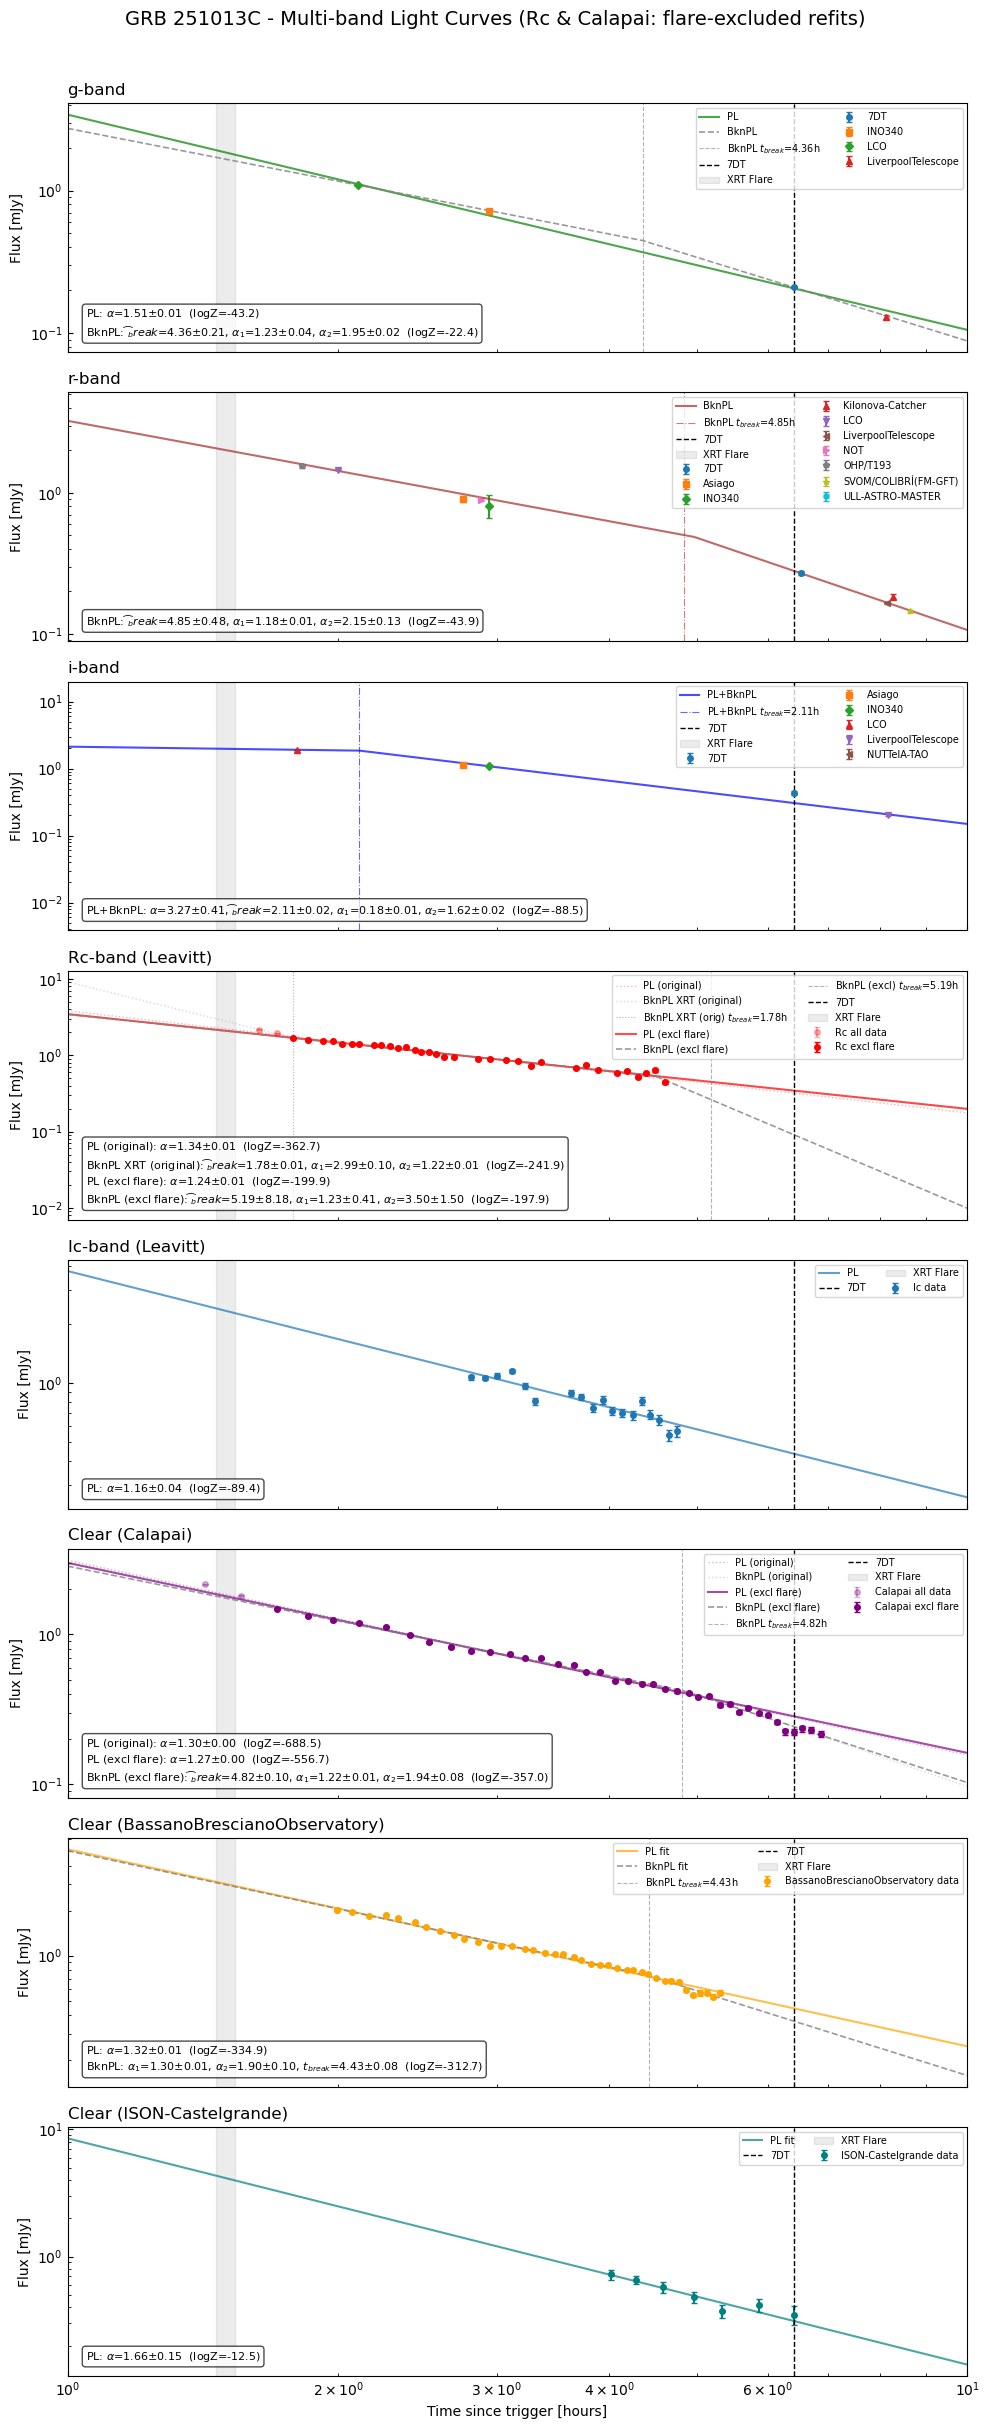

In [4]:
# Plot flare-excluded refits with all other bands for context
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from grb.functions import power_law, broken_power_law
from grb.io import read_data, filter_data

with open("excl_flare_results.pkl", "rb") as f:
    excl = pickle.load(f)
with open("fit_results.pkl", "rb") as f:
    data = pickle.load(f)
with open("var_model_results.pkl", "rb") as f:
    var_data = pickle.load(f)
with open("clear_band_results.pkl", "rb") as f:
    clear_data = pickle.load(f)

# --- Load raw circular data to get facility info ---
df_circ = read_data("circular", add_converted_flux=True)

# Per-band filtering (matching run.ipynb)
band_filters = {
    "g":  dict(filter_name=["g"], remove_upper_limits=True, exclude_time_range=(20, 1e4)),
    "r":  dict(filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4)),
    "i":  dict(filter_name="i", remove_upper_limits=True),
    "Rc": dict(filter_name=["Rc"], remove_upper_limits=True, facility_name="Leavitt"),
    "Ic": dict(filter_name=["Ic"], remove_upper_limits=True, facility_name="Leavitt"),
}
band_dfs = {band: filter_data(df_circ, **filt) for band, filt in band_filters.items()}

# --- Facility color palette ---
_facility_cmap = plt.cm.tab10
def _get_facility_colors(facilities):
    return {fac: _facility_cmap(i) for i, fac in enumerate(sorted(facilities))}

_markers = ["o", "s", "D", "^", "v", "<", ">", "p", "*", "h"]

trigger = datetime(2025, 10, 13, 17, 39, 42)
t_7dt = (datetime(2025, 10, 14, 0, 4, 15) - trigger).total_seconds() / 3600
t_flare_start = 5265 / 3600
t_flare_end = 5528 / 3600
x_min, x_max = 1, 10
t_model = np.geomspace(x_min, x_max, 300)

bands = ["g", "r", "i", "Rc", "Ic"]
band_config = {
    "g":  {"color": "green",  "model": lambda t, p: power_law(t, *p), "label": "PL"},
    "Ic": {"color": "C0",     "model": lambda t, p: power_law(t, *p), "label": "PL"},
    "Rc": {"color": "red",    "model": lambda t, p: power_law(t, *p), "label": "PL"},
    "i":  {"color": "blue",   "model": lambda t, p: power_law(t, *p[:2]) + broken_power_law(t, *p[2:]), "label": "PL+BknPL"},
    "r":  {"color": "brown",  "model": lambda t, p: broken_power_law(t, *p), "label": "BknPL"},
}
# var_model_map for non-Rc/non-Calapai bands
var_model_map = {
    "g": [
        ("g_BknPL", "BknPL", lambda t, p: broken_power_law(t, *p)),
    ],
}
clear_facilities = ["Calapai", "BassanoBrescianoObservatory", "ISON-Castelgrande"]
clear_colors = {"Calapai": "purple", "BassanoBrescianoObservatory": "orange", "ISON-Castelgrande": "teal"}

def _fmt_params(params_list, means, stds):
    parts = []
    for j, pname in enumerate(params_list):
        if pname.startswith("F"):
            continue
        parts.append(fr"$\{pname}$={means[j]:.2f}$\pm${stds[j]:.2f}")
    return ", ".join(parts)

def _draw_tbreak(ax, params_list, means, color, ls, label_prefix):
    for j, pname in enumerate(params_list):
        if pname == "t_break":
            ax.axvline(means[j], color=color, ls=ls, lw=0.8, alpha=0.6,
                       label=fr"{label_prefix} $t_{{break}}$={means[j]:.2f}h")

def _add_markers(ax):
    ax.axvline(t_7dt, color="black", ls="--", lw=1, label="7DT")
    ax.axvspan(t_flare_start, t_flare_end, color="grey", alpha=0.15, label="XRT Flare")

n_plots = len(bands) + len(clear_facilities)
fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots), sharex=True)

# === Multi-band plots ===
for ax, band in zip(axes[:len(bands)], bands):
    d = data[band]
    cfg = band_config[band]
    x = np.array(d["x_data"])
    y = np.array(d["y_data"])
    yerr = np.array(d["y_data_error"]) if d["y_data_error"] is not None else None
    param_names = d["params"]

    # Get facility info for this band
    df_band = band_dfs[band]
    facilities = df_band["Facility"].unique()
    has_multi_fac = len(facilities) > 1

    if band == "Rc":
        # --- Rc: show original faded + excl flare refits ---
        ax.errorbar(x, y, yerr=yerr, fmt="o", color=cfg["color"], ms=4, capsize=2, alpha=0.3, label="Rc all data")

        d_pl = excl["Rc_PL_excl_flare"]
        d_bk = excl["Rc_BknPL_excl_flare"]
        x_excl = np.array(d_pl["x_data"])
        y_excl = np.array(d_pl["y_data"])
        yerr_excl = np.array(d_pl["y_data_error"]) if d_pl["y_data_error"] is not None else None
        ax.errorbar(x_excl, y_excl, yerr=yerr_excl, fmt="o", color=cfg["color"], ms=4, capsize=2, label="Rc excl flare")

        # Original PL (faded)
        y_orig_pl = power_law(t_model, *d["best_fit_params"])
        ax.plot(t_model, y_orig_pl, color=cfg["color"], lw=1, alpha=0.3, ls=":", label="PL (original)")

        # Original BknPL XRT prior (faded)
        vkey = "Rc_BknPL_alpha2_from_xrt"
        if vkey in var_data:
            vd = var_data[vkey]
            y_orig_bk = broken_power_law(t_model, *vd["best_fit_params"])
            ax.plot(t_model, y_orig_bk, color="grey", lw=1, alpha=0.3, ls=":", label="BknPL XRT (original)")
            _draw_tbreak(ax, vd["params"], vd["results"]["posterior"]["mean"],
                         "grey", ":", "BknPL XRT (orig)")

        # Excl PL
        y_excl_pl = power_law(t_model, *d_pl["best_fit_params"])
        ax.plot(t_model, y_excl_pl, color=cfg["color"], lw=1.5, alpha=0.7, label="PL (excl flare)")

        # Excl BknPL
        y_excl_bk = broken_power_law(t_model, *d_bk["best_fit_params"])
        ax.plot(t_model, y_excl_bk, color="grey", lw=1.2, ls="--", alpha=0.8, label="BknPL (excl flare)")
        _draw_tbreak(ax, d_bk["params"], d_bk["results"]["posterior"]["mean"], "grey", "--", "BknPL (excl)")

        _add_markers(ax)

        orig_alpha = d["results"]["posterior"]["mean"][1]
        orig_alpha_err = d["results"]["posterior"]["stdev"][1]
        txt_lines = [
            fr"PL (original): $\alpha$={orig_alpha:.2f}$\pm${orig_alpha_err:.2f}  (logZ={d['results']['logz']:.1f})",
        ]
        if vkey in var_data:
            vd = var_data[vkey]
            txt_lines.append(f"BknPL XRT (original): {_fmt_params(vd['params'], vd['results']['posterior']['mean'], vd['results']['posterior']['stdev'])}  (logZ={vd['logz']:.1f})")
        txt_lines.append(f"PL (excl flare): {_fmt_params(d_pl['params'], d_pl['results']['posterior']['mean'], d_pl['results']['posterior']['stdev'])}  (logZ={d_pl['logz']:.1f})")
        txt_lines.append(f"BknPL (excl flare): {_fmt_params(d_bk['params'], d_bk['results']['posterior']['mean'], d_bk['results']['posterior']['stdev'])}  (logZ={d_bk['logz']:.1f})")
    else:
        # --- Other bands: plot data points colored by facility ---
        if has_multi_fac:
            fac_colors = _get_facility_colors(facilities)
            for fi, fac in enumerate(sorted(facilities)):
                mask = df_band["Facility"] == fac
                df_fac = df_band[mask]
                ax.errorbar(df_fac["Time"], df_fac["flux_mJy"],
                            yerr=df_fac["flux_error_mJy"],
                            fmt=_markers[fi % len(_markers)],
                            color=fac_colors[fac], ms=4, capsize=2,
                            label=fac)
        else:
            ax.errorbar(x, y, yerr=yerr, fmt="o", color=cfg["color"], ms=4, capsize=2, label=f"{band} data")

        y_model = cfg["model"](t_model, d["best_fit_params"])
        ax.plot(t_model, y_model, color=cfg["color"], lw=1.5, alpha=0.7, label=cfg["label"])

        # Baseline t_break
        _draw_tbreak(ax, param_names, d["results"]["posterior"]["mean"], cfg["color"], "-.", cfg["label"])

        # Overlay var_model experiments
        if band in var_model_map:
            ls_cycle = ["--", ":", "-."]
            for idx, (vkey, vlabel, vmodel) in enumerate(var_model_map[band]):
                if vkey in var_data:
                    vd = var_data[vkey]
                    y_var = vmodel(t_model, vd["best_fit_params"])
                    ax.plot(t_model, y_var, color="grey", lw=1.2, ls=ls_cycle[idx % 3],
                            alpha=0.8, label=vlabel)
                    _draw_tbreak(ax, vd["params"], vd["results"]["posterior"]["mean"],
                                 "grey", ls_cycle[idx % 3], vlabel)

        _add_markers(ax)

        base_params_str = _fmt_params(param_names, d["results"]["posterior"]["mean"], d["results"]["posterior"]["stdev"])
        txt_lines = [f"{cfg['label']}: {base_params_str}  (logZ={d['results']['logz']:.1f})"]

        # Add var_model annotations
        if band in var_model_map:
            for vkey, vlabel, _ in var_model_map[band]:
                if vkey in var_data:
                    vd = var_data[vkey]
                    alt_str = _fmt_params(vd["params"], vd["results"]["posterior"]["mean"], vd["results"]["posterior"]["stdev"])
                    txt_lines.append(f"{vlabel}: {alt_str}  (logZ={vd['logz']:.1f})")

    ax.text(0.02, 0.05, "\n".join(txt_lines), transform=ax.transAxes, fontsize=8, va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    if band == 'Rc':
        ax.set_title("Rc-band (Leavitt)", fontsize=12, loc="left")
    elif band == 'Ic':
        ax.set_title("Ic-band (Leavitt)", fontsize=12, loc="left")
    else:
        ax.set_title(f"{band}-band", fontsize=12, loc="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Flux [mJy]")
    ax.set_xlim(x_min, x_max)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.tick_params(which="both", direction="in")

# === Clear band plots ===
for ax, fac in zip(axes[len(bands):], clear_facilities):
    pl_key = f"clear_{fac}_PL"
    d_pl_orig = clear_data[pl_key]
    x_orig = np.array(d_pl_orig["x_data"])
    y_orig = np.array(d_pl_orig["y_data"])
    yerr_orig = np.array(d_pl_orig["y_data_error"]) if d_pl_orig["y_data_error"] is not None else None

    if fac == "Calapai":
        # --- Calapai: show original faded + excl flare refits ---
        ax.errorbar(x_orig, y_orig, yerr=yerr_orig, fmt="o", color=clear_colors[fac], ms=4, capsize=2, alpha=0.3, label="Calapai all data")

        d_pl = excl["clear_Calapai_PL_excl_flare"]
        d_bk = excl["clear_Calapai_BknPL_excl_flare"]
        x_excl = np.array(d_pl["x_data"])
        y_excl = np.array(d_pl["y_data"])
        yerr_excl = np.array(d_pl["y_data_error"]) if d_pl["y_data_error"] is not None else None
        ax.errorbar(x_excl, y_excl, yerr=yerr_excl, fmt="o", color=clear_colors[fac], ms=4, capsize=2, label="Calapai excl flare")

        # Original PL (faded)
        y_orig_pl = power_law(t_model, *d_pl_orig["best_fit_params"])
        ax.plot(t_model, y_orig_pl, color=clear_colors[fac], lw=1, alpha=0.3, ls=":", label="PL (original)")

        # Original BknPL (faded)
        bk_orig_key = f"clear_{fac}_BknPL"
        if bk_orig_key in clear_data:
            y_orig_bk = broken_power_law(t_model, *clear_data[bk_orig_key]["best_fit_params"])
            ax.plot(t_model, y_orig_bk, color="grey", lw=1, alpha=0.3, ls=":", label="BknPL (original)")

        # Excl PL
        y_excl_pl = power_law(t_model, *d_pl["best_fit_params"])
        ax.plot(t_model, y_excl_pl, color=clear_colors[fac], lw=1.5, alpha=0.7, label="PL (excl flare)")

        # Excl BknPL
        y_excl_bk = broken_power_law(t_model, *d_bk["best_fit_params"])
        ax.plot(t_model, y_excl_bk, color="grey", lw=1.2, ls="--", alpha=0.8, label="BknPL (excl flare)")
        _draw_tbreak(ax, d_bk["params"], d_bk["results"]["posterior"]["mean"], "grey", "--", "BknPL")

        _add_markers(ax)

        txt_lines = [
            fr"PL (original): $\alpha$={d_pl_orig['alpha_mean']:.2f}$\pm${d_pl_orig['alpha_std']:.2f}  (logZ={d_pl_orig['logz']:.1f})",
            f"PL (excl flare): {_fmt_params(d_pl['params'], d_pl['results']['posterior']['mean'], d_pl['results']['posterior']['stdev'])}  (logZ={d_pl['logz']:.1f})",
            f"BknPL (excl flare): {_fmt_params(d_bk['params'], d_bk['results']['posterior']['mean'], d_bk['results']['posterior']['stdev'])}  (logZ={d_bk['logz']:.1f})",
        ]
    else:
        # --- Other clear facilities: normal plot ---
        ax.errorbar(x_orig, y_orig, yerr=yerr_orig, fmt="o", color=clear_colors[fac], ms=4, capsize=2, label=f"{fac} data")

        y_pl = power_law(t_model, *d_pl_orig["best_fit_params"])
        ax.plot(t_model, y_pl, color=clear_colors[fac], lw=1.5, alpha=0.7, label="PL fit")

        bknpl_key = f"clear_{fac}_BknPL"
        if bknpl_key in clear_data:
            d_bk = clear_data[bknpl_key]
            y_bk = broken_power_law(t_model, *d_bk["best_fit_params"])
            ax.plot(t_model, y_bk, color="grey", lw=1.2, ls="--", alpha=0.8, label="BknPL fit")
            _draw_tbreak(ax, d_bk["params"], d_bk["results"]["posterior"]["mean"], "grey", "--", "BknPL")

        _add_markers(ax)

        txt_lines = [fr"PL: $\alpha$={d_pl_orig['alpha_mean']:.2f}$\pm${d_pl_orig['alpha_std']:.2f}  (logZ={d_pl_orig['logz']:.1f})"]
        if bknpl_key in clear_data:
            d_bk = clear_data[bknpl_key]
            means = d_bk["results"]["posterior"]["mean"]
            stds = d_bk["results"]["posterior"]["stdev"]
            txt_lines.append(fr"BknPL: $\alpha_1$={means[2]:.2f}$\pm${stds[2]:.2f}, $\alpha_2$={means[3]:.2f}$\pm${stds[3]:.2f}, $t_{{break}}$={means[1]:.2f}$\pm${stds[1]:.2f}  (logZ={d_bk['logz']:.1f})")

    ax.text(0.02, 0.05, "\n".join(txt_lines), transform=ax.transAxes, fontsize=8, va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    ax.set_title(f"Clear ({fac})", fontsize=12, loc="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Flux [mJy]")
    ax.set_xlim(x_min, x_max)
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.tick_params(which="both", direction="in")

axes[-1].set_xlabel("Time since trigger [hours]")
fig.suptitle("GRB 251013C - Multi-band Light Curves (Rc & Calapai: flare-excluded refits)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("excl_flare_refit.png", dpi=300, bbox_inches="tight")
plt.show()